In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

caiso = pd.read_csv("../data/caiso_demand_2023_full_year.csv")

caiso["datetime"] = pd.to_datetime(caiso["datetime"])

print("Number of observations:", len(caiso))
print("\nColumns:")
print(caiso.columns)

caiso.head()

Number of observations: 8760

Columns:
Index(['datetime', 'respondent', 'respondent-name', 'type-name', 'demand_mwh'], dtype='str')


,datetime,respondent,respondent-name,type-name,demand_mwh
0,2023-01-01 00:00:00,CISO,California Independent System Operator,Demand,24007.0
1,2023-01-01 01:00:00,CISO,California Independent System Operator,Demand,24546.0
2,2023-01-01 02:00:00,CISO,California Independent System Operator,Demand,25344.0
3,2023-01-01 03:00:00,CISO,California Independent System Operator,Demand,26468.0
4,2023-01-01 04:00:00,CISO,California Independent System Operator,Demand,26047.0


In [15]:

caiso_clean = caiso[["datetime", "demand_mwh"]].copy()

caiso_clean = caiso_clean.sort_values("datetime")

caiso_clean = caiso_clean.drop_duplicates(subset="datetime")
print("Missing values:")
print(caiso_clean.isna().sum())

print("\nDuplicate timestamps:")
print(caiso_clean["datetime"].duplicated().sum())

print("\nDate range:")
print(caiso_clean["datetime"].min(), "to", caiso_clean["datetime"].max())

print("\nFinal shape:", caiso_clean.shape)

caiso_clean.head()

Missing values:
datetime      0
demand_mwh    2
dtype: int64

Duplicate timestamps:
0

Date range:
2023-01-01 00:00:00 to 2023-12-31 23:00:00

Final shape: (8760, 2)


,datetime,demand_mwh
0,2023-01-01 00:00:00,24007.0
1,2023-01-01 01:00:00,24546.0
2,2023-01-01 02:00:00,25344.0
3,2023-01-01 03:00:00,26468.0
4,2023-01-01 04:00:00,26047.0


In [16]:

caiso_clean = caiso[["datetime", "demand_mwh"]].copy()

caiso_clean["datetime"] = pd.to_datetime(caiso_clean["datetime"])
caiso_clean = (
    caiso_clean
    .dropna()
    .drop_duplicates(subset="datetime")
    .sort_values("datetime")
    .reset_index(drop=True)
)

print("Shape:", caiso_clean.shape)
print("Missing values:")
print(caiso_clean.isna().sum())

print("\nDate range:")
print(caiso_clean["datetime"].min(), "to", caiso_clean["datetime"].max())

caiso_clean.head()

Shape: (8758, 2)
Missing values:
datetime      0
demand_mwh    0
dtype: int64

Date range:
2023-01-01 00:00:00 to 2023-12-31 23:00:00


,datetime,demand_mwh
0,2023-01-01 00:00:00,24007.0
1,2023-01-01 01:00:00,24546.0
2,2023-01-01 02:00:00,25344.0
3,2023-01-01 03:00:00,26468.0
4,2023-01-01 04:00:00,26047.0


In [17]:
stations = pd.DataFrame({
    "station_name": [
        "San Francisco International Airport",
        "Los Angeles International Airport",
        "Sacramento International Airport",
        "Fresno Yosemite International Airport",
        "San Diego International Airport"
    ],
    "short_name": [
        "SFO",
        "LAX",
        "SAC",
        "FRESNO",
        "SAN_DIEGO"
    ],
    "latitude": [
        37.6213,
        33.9416,
        38.6954,
        36.7762,
        32.7338
    ],
    "longitude": [
        -122.3790,
        -118.4085,
        -121.5908,
        -119.7181,
        -117.1933
    ]
})

stations

,station_name,short_name,latitude,longitude
0,San Francisco International Airport,SFO,37.6213,-122.3790
1,Los Angeles International Airport,LAX,33.9416,-118.4085
2,Sacramento International Airport,SAC,38.6954,-121.5908
3,Fresno Yosemite International Airport,FRESNO,36.7762,-119.7181
4,San Diego International Airport,SAN_DIEGO,32.7338,-117.1933


In [5]:

!pip install meteostat

In [18]:
import meteostat

print(meteostat.__version__)
print(dir(meteostat))

2.1.4
['Granularity', 'Inventory', 'License', 'Parameter', 'Point', 'Provider', 'Station', 'TimeSeries', 'UnitSystem', '__all__', '__appname__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'api', 'config', 'core', 'daily', 'enumerations', 'hourly', 'interpolate', 'interpolation', 'lapse_rate', 'merge', 'monthly', 'normals', 'parameters', 'providers', 'purge', 'stations', 'typing', 'utils']


In [19]:
import meteostat

print(meteostat.__file__)

C:\Users\magara cliff\miniconda3\envs\aegis_project\Lib\site-packages\meteostat\__init__.py


In [20]:
import meteostat as ms
from datetime import datetime

In [21]:
import meteostat as ms
from datetime import datetime

# SFO location
sfo_point = ms.Point(37.6213, -122.3790)

# Full year of 2023
start = datetime(2023, 1, 1, 0, 0)
end = datetime(2023, 12, 31, 23, 59)

sfo_ts = ms.hourly(
    sfo_point,
    start,
    end,
    timezone="America/Los_Angeles"
)

sfo_weather = sfo_ts.fetch()

print("Shape:", sfo_weather.shape)
print("Columns:", sfo_weather.columns.tolist())
sfo_weather.head()

AttributeError: 'NoneType' object has no attribute 'shape'

In [22]:
import meteostat as ms

sfo_point = ms.Point(37.6213, -122.3790)

nearby_sfo = ms.stations.nearby(
    sfo_point,
    limit=10
)

nearby_sfo

,name,country,region,latitude,longitude,elevation,timezone,distance
id,,,,,,,,
72494,San Francisco Airport,US,CA,37.6167,-122.3667,3,America/Los_Angeles,1198.0
KHAF0,Half Moon Bay / El Granada Mobile Home Park,US,CA,37.5134,-122.5012,20,America/Los_Angeles,16123.0
72493,Metro Oakland International Airport,US,CA,37.7167,-122.2333,2,America/Los_Angeles,16642.9
KSQL0,San Carlos / Silver Penny Mobile Home Park,US,CA,37.5119,-122.2495,2,America/Los_Angeles,16681.0
74506,Alameda Naval Air Station,US,CA,37.7833,-122.3167,4,America/Los_Angeles,18829.0
72585,Hayward / Russell City,US,CA,37.6589,-122.1218,16,America/Los_Angeles,23029.4
KPAO0,Palo Alto / Runnymeade (Historical),US,CA,37.4611,-122.1151,2,America/Los_Angeles,29303.5
74509,Moffett Field,US,CA,37.4333,-122.0500,10,America/Los_Angeles,35759.5
KSJC0,San Jose / Santa Clara Trailer Village,US,CA,37.3627,-121.9291,19,America/Los_Angeles,49014.0


In [23]:
import meteostat as ms
from datetime import datetime

start = datetime(2023, 1, 1)
end = datetime(2023, 12, 31, 23)

weather = ms.hourly(
    "72494",
    start,
    end,
    timezone="America/Los_Angeles"
).fetch()

weather.head()

,temp,rhum,prcp,snwd,wdir,wspd,wpgt,pres,tsun,cldc,coco
time,,,,,,,,,,,
2023-01-01 00:00:00-08:00,12.2,77,0.0,<NA>,270,25.9,<NA>,1008.3,<NA>,2,2
2023-01-01 01:00:00-08:00,11.1,83,0.0,<NA>,260,16.6,<NA>,1008.2,<NA>,4,2
2023-01-01 02:00:00-08:00,10.6,83,0.0,<NA>,240,11.2,<NA>,1008.2,<NA>,2,2
2023-01-01 03:00:00-08:00,10.6,83,0.0,<NA>,250,22.3,<NA>,1008.6,<NA>,0,2
2023-01-01 04:00:00-08:00,11.1,77,0.0,<NA>,250,33.5,<NA>,1009.2,<NA>,0,2


In [24]:

sfo_weather = weather.reset_index().copy()

sfo_weather["time"] = pd.to_datetime(sfo_weather["time"])

sfo_weather["datetime"] = sfo_weather["time"].dt.tz_localize(None)

sfo_weather = sfo_weather[
    [
        "datetime",
        "temp",
        "rhum",
        "prcp",
        "wspd",
        "pres"
    ]
].copy()

sfo_weather = sfo_weather.rename(columns={
    "temp": "temp_sfo",
    "rhum": "humidity_sfo",
    "prcp": "precip_sfo",
    "wspd": "wind_sfo",
    "pres": "pressure_sfo"
})

print("SFO weather shape:", sfo_weather.shape)
print("\nMissing values:")
print(sfo_weather.isna().sum())

sfo_weather.head()

SFO weather shape: (8760, 6)

Missing values:
datetime          0
temp_sfo          0
humidity_sfo      0
precip_sfo      349
wind_sfo          0
pressure_sfo      0
dtype: int64


,datetime,temp_sfo,humidity_sfo,precip_sfo,wind_sfo,pressure_sfo
0,2023-01-01 00:00:00,12.2,77,0.0,25.9,1008.3
1,2023-01-01 01:00:00,11.1,83,0.0,16.6,1008.2
2,2023-01-01 02:00:00,10.6,83,0.0,11.2,1008.2
3,2023-01-01 03:00:00,10.6,83,0.0,22.3,1008.6
4,2023-01-01 04:00:00,11.1,77,0.0,33.5,1009.2


In [25]:
import meteostat as ms
import pandas as pd
from datetime import datetime

start = datetime(2023, 1, 1)
end = datetime(2023, 12, 31, 23)


def download_airport_weather(short_name, latitude, longitude):
    """
    Find the closest Meteostat station, download its 2023 hourly weather,
    clean timestamps, and rename columns using the location name.
    """

    point = ms.Point(latitude, longitude)

    nearby = ms.stations.nearby(point, limit=5)

    if nearby is None or nearby.empty:
        raise ValueError(f"No nearby station found for {short_name}")

    station_id = str(nearby.index[0])
    station_name = nearby.iloc[0]["name"]

    print(
        f"{short_name}: using station {station_id} — {station_name}"
    )

    hourly_data = ms.hourly(
        station_id,
        start,
        end,
        timezone="America/Los_Angeles"
    ).fetch()

    if hourly_data is None or hourly_data.empty:
        raise ValueError(
            f"No hourly weather data returned for {short_name}"
        )

    hourly_data = hourly_data.reset_index()


    hourly_data["datetime"] = (
        pd.to_datetime(hourly_data["time"])
        .dt.tz_localize(None)
    )


    desired_columns = [
        "datetime",
        "temp",
        "rhum",
        "prcp",
        "wspd",
        "pres"
    ]

    available_columns = [
        column
        for column in desired_columns
        if column in hourly_data.columns
    ]

    hourly_data = hourly_data[available_columns].copy()


    rename_map = {
        "temp": f"temp_{short_name.lower()}",
        "rhum": f"humidity_{short_name.lower()}",
        "prcp": f"precip_{short_name.lower()}",
        "wspd": f"wind_{short_name.lower()}",
        "pres": f"pressure_{short_name.lower()}"
    }

    hourly_data = hourly_data.rename(columns=rename_map)

    hourly_data = (
        hourly_data
        .drop_duplicates(subset="datetime")
        .sort_values("datetime")
        .reset_index(drop=True)
    )

    return hourly_data

In [26]:
weather_datasets = {}

for _, row in stations.iterrows():
    short_name = row["short_name"]

    try:
        weather_datasets[short_name] = download_airport_weather(
            short_name=short_name,
            latitude=row["latitude"],
            longitude=row["longitude"]
        )

        print(
            f"Downloaded {len(weather_datasets[short_name])} "
            f"hourly rows for {short_name}\n"
        )

    except Exception as error:
        print(f"Could not download {short_name}: {error}\n")

SFO: using station 72494 — San Francisco Airport
Downloaded 8759 hourly rows for SFO

LAX: using station 72295 — Los Angeles Airport
Downloaded 8759 hourly rows for LAX

SAC: using station KSMF0 — Sacramento / Kiesel
Downloaded 8759 hourly rows for SAC

FRESNO: using station 72389 — Fresno Air Terminal
Downloaded 8759 hourly rows for FRESNO

SAN_DIEGO: using station 72290 — San Diego International Airport
Downloaded 8759 hourly rows for SAN_DIEGO



In [27]:
from functools import reduce

weather_list = list(weather_datasets.values())

weather_all = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on="datetime",
        how="outer"
    ),
    weather_list
)

weather_all = (
    weather_all
    .sort_values("datetime")
    .drop_duplicates(subset="datetime")
    .reset_index(drop=True)
)

print("Combined weather shape:", weather_all.shape)
print("\nDate range:")
print(weather_all["datetime"].min(), "to", weather_all["datetime"].max())

print("\nMissing values by column:")
print(weather_all.isna().sum())

weather_all.head()

Combined weather shape: (8759, 26)

Date range:
2023-01-01 00:00:00 to 2023-12-31 23:00:00

Missing values by column:
datetime                0
temp_sfo                0
humidity_sfo            0
precip_sfo            349
wind_sfo                0
pressure_sfo            0
temp_lax                0
humidity_lax            0
precip_lax            244
wind_lax                0
pressure_lax            0
temp_sac                0
humidity_sac            0
precip_sac            282
wind_sac                0
pressure_sac            0
temp_fresno             0
humidity_fresno         0
precip_fresno         249
wind_fresno             0
pressure_fresno         0
temp_san_diego          0
humidity_san_diego      0
precip_san_diego      355
wind_san_diego          0
pressure_san_diego      0
dtype: int64


,datetime,temp_sfo,humidity_sfo,precip_sfo,wind_sfo,pressure_sfo,temp_lax,humidity_lax,precip_lax,wind_lax,...,temp_fresno,humidity_fresno,precip_fresno,wind_fresno,pressure_fresno,temp_san_diego,humidity_san_diego,precip_san_diego,wind_san_diego,pressure_san_diego
0,2023-01-01 00:00:00,12.2,77,0.0,25.9,1008.3,14.4,93,3.0,35.3,...,10.0,93,0.0,9.4,1005.6,15.0,93,0.3,25.9,1010.7
1,2023-01-01 01:00:00,11.1,83,0.0,16.6,1008.2,13.9,83,<NA>,40.7,...,10.0,83,0.0,18.4,1005.6,15.0,90,0.7,35.3,1010.0
2,2023-01-01 02:00:00,10.6,83,0.0,11.2,1008.2,13.3,84,0.0,38.9,...,8.9,100,0.8,13.0,1005.8,15.6,90,0.5,18.4,1009.0
3,2023-01-01 03:00:00,10.6,83,0.0,22.3,1008.6,13.3,80,0.0,38.9,...,8.9,100,1.8,13.0,1005.9,15.6,90,1.2,29.5,1008.0
4,2023-01-01 04:00:00,11.1,77,0.0,33.5,1009.2,12.8,83,0.0,14.8,...,8.9,100,1.8,13.0,1005.6,14.4,78,2.0,25.9,1008.2


In [ ]:
temperature_columns = [
    "temp_sfo",
    "temp_lax",
    "temp_sac",
    "temp_fresno",
    "temp_san_diego"
]

weather_all["temp_average"] = weather_all[temperature_columns].mean(axis=1)
weather_all["temp_max"] = weather_all[temperature_columns].max(axis=1)
weather_all["temp_min"] = weather_all[temperature_columns].min(axis=1)
weather_all["temp_range"] = (
    weather_all["temp_max"] - weather_all["temp_min"]
)

print(
    weather_all[
        [
            "datetime",
            "temp_average",
            "temp_max",
            "temp_min",
            "temp_range"
        ]
    ].head()
)

In [28]:
combined_data = pd.merge(
    caiso_clean,
    weather_all,
    on="datetime",
    how="left"
)

print("Merged shape:", combined_data.shape)

print("\nMissing values after merge:")
print(combined_data.isna().sum())

combined_data.head()

Merged shape: (8758, 27)

Missing values after merge:
datetime                0
demand_mwh              0
temp_sfo                1
humidity_sfo            1
precip_sfo            350
wind_sfo                1
pressure_sfo            1
temp_lax                1
humidity_lax            1
precip_lax            245
wind_lax                1
pressure_lax            1
temp_sac                1
humidity_sac            1
precip_sac            283
wind_sac                1
pressure_sac            1
temp_fresno             1
humidity_fresno         1
precip_fresno         250
wind_fresno             1
pressure_fresno         1
temp_san_diego          1
humidity_san_diego      1
precip_san_diego      356
wind_san_diego          1
pressure_san_diego      1
dtype: int64


,datetime,demand_mwh,temp_sfo,humidity_sfo,precip_sfo,wind_sfo,pressure_sfo,temp_lax,humidity_lax,precip_lax,...,temp_fresno,humidity_fresno,precip_fresno,wind_fresno,pressure_fresno,temp_san_diego,humidity_san_diego,precip_san_diego,wind_san_diego,pressure_san_diego
0,2023-01-01 00:00:00,24007.0,12.2,77,0.0,25.9,1008.3,14.4,93,3.0,...,10.0,93,0.0,9.4,1005.6,15.0,93,0.3,25.9,1010.7
1,2023-01-01 01:00:00,24546.0,11.1,83,0.0,16.6,1008.2,13.9,83,<NA>,...,10.0,83,0.0,18.4,1005.6,15.0,90,0.7,35.3,1010.0
2,2023-01-01 02:00:00,25344.0,10.6,83,0.0,11.2,1008.2,13.3,84,0.0,...,8.9,100,0.8,13.0,1005.8,15.6,90,0.5,18.4,1009.0
3,2023-01-01 03:00:00,26468.0,10.6,83,0.0,22.3,1008.6,13.3,80,0.0,...,8.9,100,1.8,13.0,1005.9,15.6,90,1.2,29.5,1008.0
4,2023-01-01 04:00:00,26047.0,11.1,77,0.0,33.5,1009.2,12.8,83,0.0,...,8.9,100,1.8,13.0,1005.6,14.4,78,2.0,25.9,1008.2


In [29]:
combined_data = pd.merge(
    caiso,
    weather_all,
    on="datetime",
    how="left"
)

print(combined_data.shape)
combined_data.head()

(8760, 30)


,datetime,respondent,respondent-name,type-name,demand_mwh,temp_sfo,humidity_sfo,precip_sfo,wind_sfo,pressure_sfo,...,temp_fresno,humidity_fresno,precip_fresno,wind_fresno,pressure_fresno,temp_san_diego,humidity_san_diego,precip_san_diego,wind_san_diego,pressure_san_diego
0,2023-01-01 00:00:00,CISO,California Independent System Operator,Demand,24007.0,12.2,77,0.0,25.9,1008.3,...,10.0,93,0.0,9.4,1005.6,15.0,93,0.3,25.9,1010.7
1,2023-01-01 01:00:00,CISO,California Independent System Operator,Demand,24546.0,11.1,83,0.0,16.6,1008.2,...,10.0,83,0.0,18.4,1005.6,15.0,90,0.7,35.3,1010.0
2,2023-01-01 02:00:00,CISO,California Independent System Operator,Demand,25344.0,10.6,83,0.0,11.2,1008.2,...,8.9,100,0.8,13.0,1005.8,15.6,90,0.5,18.4,1009.0
3,2023-01-01 03:00:00,CISO,California Independent System Operator,Demand,26468.0,10.6,83,0.0,22.3,1008.6,...,8.9,100,1.8,13.0,1005.9,15.6,90,1.2,29.5,1008.0
4,2023-01-01 04:00:00,CISO,California Independent System Operator,Demand,26047.0,11.1,77,0.0,33.5,1009.2,...,8.9,100,1.8,13.0,1005.6,14.4,78,2.0,25.9,1008.2


In [30]:
combined_data.isna().sum()

datetime                0
respondent              0
respondent-name         0
type-name               0
demand_mwh              2
temp_sfo                1
humidity_sfo            1
precip_sfo            350
wind_sfo                1
pressure_sfo            1
temp_lax                1
humidity_lax            1
precip_lax            245
wind_lax                1
pressure_lax            1
temp_sac                1
humidity_sac            1
precip_sac            283
wind_sac                1
pressure_sac            1
temp_fresno             1
humidity_fresno         1
precip_fresno         250
wind_fresno             1
pressure_fresno         1
temp_san_diego          1
humidity_san_diego      1
precip_san_diego      356
wind_san_diego          1
pressure_san_diego      1
dtype: int64

visualize the relationship between weather and demand
Electricity Demand vs Average California Temperature.

In [31]:
plt.figure(figsize=(15,6))

plt.scatter(
    combined_data["temp_average"],
    combined_data["demand_mwh"],
    alpha=0.25,
    s=8
)

plt.xlabel("Average California Temperature (°C)")
plt.ylabel("Electricity Demand (MWh)")
plt.title("CAISO Electricity Demand vs Average California Temperature")

plt.grid(alpha=0.3)
plt.show()

KeyError: 'temp_average'

<Figure size 1500x600 with 0 Axes>

KeyError: 'temp_average'

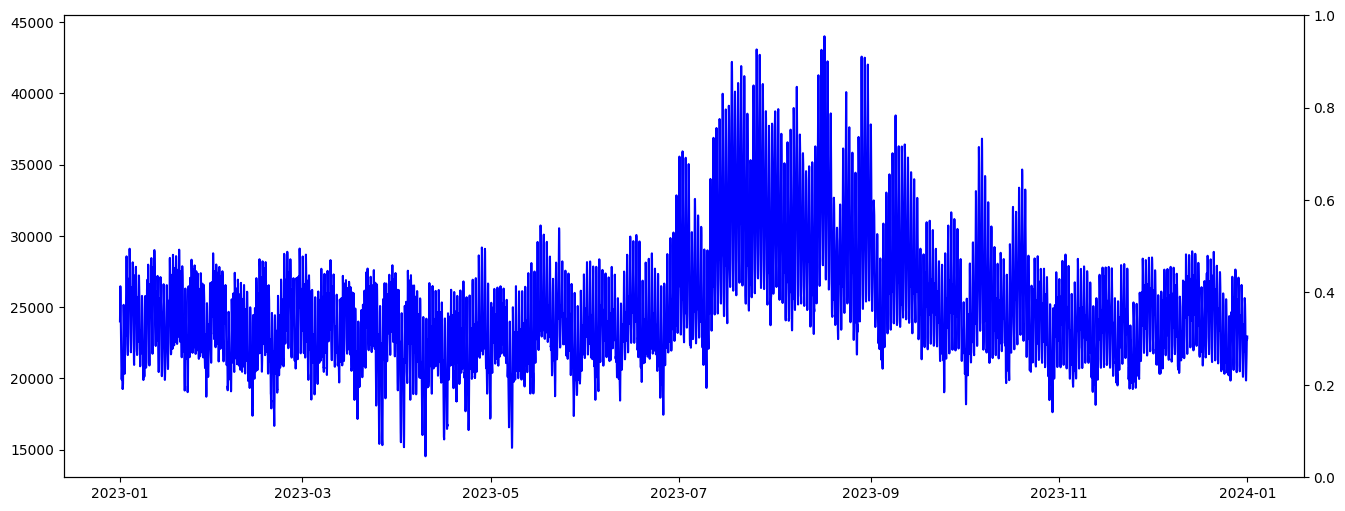

In [32]:
fig, ax1 = plt.subplots(figsize=(16,6))

ax1.plot(
    combined_data["datetime"],
    combined_data["demand_mwh"],
    color="blue",
    label="Demand"
)

ax2 = ax1.twinx()

ax2.plot(
    combined_data["datetime"],
    combined_data["temp_average"],
    color="red",
    alpha=0.7,
    label="Temperature"
)

ax1.set_ylabel("Demand (MWh)")
ax2.set_ylabel("Temperature (°C)")
ax1.set_title("Electricity Demand and Average California Temperature")

plt.show()

In [33]:
print("Combined data shape:", combined_data.shape)
print("\nColumns:")
print(combined_data.columns.tolist())

print("\nMissing values:")
print(combined_data.isna().sum())

combined_data.head()

Combined data shape: (8760, 30)

Columns:
['datetime', 'respondent', 'respondent-name', 'type-name', 'demand_mwh', 'temp_sfo', 'humidity_sfo', 'precip_sfo', 'wind_sfo', 'pressure_sfo', 'temp_lax', 'humidity_lax', 'precip_lax', 'wind_lax', 'pressure_lax', 'temp_sac', 'humidity_sac', 'precip_sac', 'wind_sac', 'pressure_sac', 'temp_fresno', 'humidity_fresno', 'precip_fresno', 'wind_fresno', 'pressure_fresno', 'temp_san_diego', 'humidity_san_diego', 'precip_san_diego', 'wind_san_diego', 'pressure_san_diego']

Missing values:
datetime                0
respondent              0
respondent-name         0
type-name               0
demand_mwh              2
temp_sfo                1
humidity_sfo            1
precip_sfo            350
wind_sfo                1
pressure_sfo            1
temp_lax                1
humidity_lax            1
precip_lax            245
wind_lax                1
pressure_lax            1
temp_sac                1
humidity_sac            1
precip_sac            283
wind_

,datetime,respondent,respondent-name,type-name,demand_mwh,temp_sfo,humidity_sfo,precip_sfo,wind_sfo,pressure_sfo,...,temp_fresno,humidity_fresno,precip_fresno,wind_fresno,pressure_fresno,temp_san_diego,humidity_san_diego,precip_san_diego,wind_san_diego,pressure_san_diego
0,2023-01-01 00:00:00,CISO,California Independent System Operator,Demand,24007.0,12.2,77,0.0,25.9,1008.3,...,10.0,93,0.0,9.4,1005.6,15.0,93,0.3,25.9,1010.7
1,2023-01-01 01:00:00,CISO,California Independent System Operator,Demand,24546.0,11.1,83,0.0,16.6,1008.2,...,10.0,83,0.0,18.4,1005.6,15.0,90,0.7,35.3,1010.0
2,2023-01-01 02:00:00,CISO,California Independent System Operator,Demand,25344.0,10.6,83,0.0,11.2,1008.2,...,8.9,100,0.8,13.0,1005.8,15.6,90,0.5,18.4,1009.0
3,2023-01-01 03:00:00,CISO,California Independent System Operator,Demand,26468.0,10.6,83,0.0,22.3,1008.6,...,8.9,100,1.8,13.0,1005.9,15.6,90,1.2,29.5,1008.0
4,2023-01-01 04:00:00,CISO,California Independent System Operator,Demand,26047.0,11.1,77,0.0,33.5,1009.2,...,8.9,100,1.8,13.0,1005.6,14.4,78,2.0,25.9,1008.2


In [34]:
print("Combined data shape:", combined_data.shape)

print("\nColumns:")
print(combined_data.columns.tolist())

print("\nMissing values:")
print(combined_data.isna().sum().sort_values(ascending=False))

Combined data shape: (8760, 30)

Columns:
['datetime', 'respondent', 'respondent-name', 'type-name', 'demand_mwh', 'temp_sfo', 'humidity_sfo', 'precip_sfo', 'wind_sfo', 'pressure_sfo', 'temp_lax', 'humidity_lax', 'precip_lax', 'wind_lax', 'pressure_lax', 'temp_sac', 'humidity_sac', 'precip_sac', 'wind_sac', 'pressure_sac', 'temp_fresno', 'humidity_fresno', 'precip_fresno', 'wind_fresno', 'pressure_fresno', 'temp_san_diego', 'humidity_san_diego', 'precip_san_diego', 'wind_san_diego', 'pressure_san_diego']

Missing values:
precip_san_diego      356
precip_sfo            350
precip_sac            283
precip_fresno         250
precip_lax            245
demand_mwh              2
pressure_sfo            1
temp_lax                1
humidity_lax            1
wind_lax                1
pressure_lax            1
wind_sfo                1
humidity_sfo            1
temp_sfo                1
humidity_fresno         1
temp_fresno             1
pressure_fresno         1
wind_fresno             1
wind_

In [35]:

model_data = combined_data.copy()

model_data = model_data.sort_values("datetime").reset_index(drop=True)

precip_cols = [col for col in model_data.columns if col.startswith("precip_")]
model_data[precip_cols] = model_data[precip_cols].fillna(0)


weather_cols = [
    col for col in model_data.select_dtypes(include="number").columns
    if col != "demand_mwh" and col not in precip_cols
]

model_data[weather_cols] = (
    model_data[weather_cols]
    .interpolate(method="linear", limit_direction="both")
)

model_data["demand_mwh"] = (
    model_data["demand_mwh"]
    .interpolate(method="linear", limit_direction="both")
)

print("Remaining missing values:", model_data.isna().sum().sum())
print("Model data shape:", model_data.shape)

model_data.head()

Remaining missing values: 0
Model data shape: (8760, 30)


,datetime,respondent,respondent-name,type-name,demand_mwh,temp_sfo,humidity_sfo,precip_sfo,wind_sfo,pressure_sfo,...,temp_fresno,humidity_fresno,precip_fresno,wind_fresno,pressure_fresno,temp_san_diego,humidity_san_diego,precip_san_diego,wind_san_diego,pressure_san_diego
0,2023-01-01 00:00:00,CISO,California Independent System Operator,Demand,24007.0,12.2,77.0,0.0,25.9,1008.3,...,10.0,93.0,0.0,9.4,1005.6,15.0,93.0,0.3,25.9,1010.7
1,2023-01-01 01:00:00,CISO,California Independent System Operator,Demand,24546.0,11.1,83.0,0.0,16.6,1008.2,...,10.0,83.0,0.0,18.4,1005.6,15.0,90.0,0.7,35.3,1010.0
2,2023-01-01 02:00:00,CISO,California Independent System Operator,Demand,25344.0,10.6,83.0,0.0,11.2,1008.2,...,8.9,100.0,0.8,13.0,1005.8,15.6,90.0,0.5,18.4,1009.0
3,2023-01-01 03:00:00,CISO,California Independent System Operator,Demand,26468.0,10.6,83.0,0.0,22.3,1008.6,...,8.9,100.0,1.8,13.0,1005.9,15.6,90.0,1.2,29.5,1008.0
4,2023-01-01 04:00:00,CISO,California Independent System Operator,Demand,26047.0,11.1,77.0,0.0,33.5,1009.2,...,8.9,100.0,1.8,13.0,1005.6,14.4,78.0,2.0,25.9,1008.2


# Weather-Enhanced Forecasting

Our objective is ; Does adding weather improve electricity demand forecasting?

In [36]:
# creating ML features.

features = [
    "temp_average",
    "temp_max",
    "temp_min",
    "temp_range",
    "humidity_sfo",
    "humidity_lax",
    "humidity_sac",
    "humidity_fresno",
    "humidity_san_diego",
    "wind_sfo",
    "wind_lax",
    "wind_sac",
    "wind_fresno",
    "wind_san_diego",
    "precip_sfo",
    "precip_lax",
    "precip_sac",
    "precip_fresno",
    "precip_san_diego"
]

X = model_data[features]
y = model_data["demand_mwh"]

print("Feature matrix:", X.shape)
print("Target:", y.shape)

X.head()

KeyError: "['temp_average', 'temp_max', 'temp_min', 'temp_range'] not in index"

# Split Training and Testing Data

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

NameError: name 'X' is not defined

# Train First Weather Model

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

print("Random Forest trained successfully!")

# Evaluate the Model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

# Objective

Integrate NOAA California weather data with the 2023 CAISO hourly electricity demand dataset to evaluate whether weather variables improve electricity demand forecasting and create a richer dataset for machine learning.

# Data Integration
Successfully merged 8,760 hourly CAISO observations with NOAA weather data from:
San Francisco
Los Angeles
Sacramento
Fresno
San Diego

Final dataset contained 8,760 observations and 34 variables, including electricity demand, temperature, humidity, wind speed, atmospheric pressure, precipitation, and statewide temperature summary features.

# Data Cleaning
Filled missing precipitation values with 0.
Applied linear interpolation to missing weather and demand values.
Sorted data chronologically and verified no duplicate timestamps.
Final dataset contained 0 missing values and was ready for machine learning analysis.

# Key Findings
Electricity demand peaked during the summer months (July–September).
Higher temperatures generally corresponded with higher electricity demand.
Winter months showed lower temperatures and lower electricity demand.
Weather demonstrated a clear influence on electricity demand but is not the only factor affecting consumption.

# performance 
| Metric       |          Result |
| ------------ | --------------: |
| **MAE**      | **1,939.99 MW** |
| **RMSE**     | **2,403.55 MW** |
| **R² Score** |      **0.0186** |

# Key Findings
The Random Forest model captured a small relationship between weather and electricity demand but achieved limited predictive performance.
The low R² (0.0186) indicates that weather variables alone explain only a small portion of the variation in hourly electricity demand.
Electricity demand is influenced by additional factors, including:
Hour of day
Day of week
Seasonal patterns
Historical demand (lag features)
Holidays and human activity

# Conclusion
Successfully integrated NOAA weather data with CAISO electricity demand, producing a clean dataset of 8,760 observations and 34 variables with no missing values.
Weather shows a meaningful relationship with electricity demand but is not sufficient on its own for accurate forecasting.
Future work will improve forecasting accuracy by incorporating time-based features, lag variables, and advanced models such as SARIMAX with exogenous variables, XGBoost, and hybrid machine learning approaches.


In [38]:
# Find the Most Important Weather Variables

import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()


NameError: name 'X' is not defined

# Feature Importance Analysis
A Random Forest feature importance analysis was conducted to identify the weather variables with the greatest influence on electricity demand.

# Key Findings;

Humidity in San Diego was the most influential predictor (26.7% importance).
Average temperature was the second most important feature (21.3% importance).
Humidity in San Francisco ranked third (9.8% importance).
Temperature-related variables (average, minimum, maximum, and range) consistently ranked among the most important predictors.
Wind variables contributed moderately to the model.
Precipitation variables had the lowest importance, indicating minimal influence on hourly electricity demand in this dataset.

# Conclusion
The feature importance analysis indicates that temperature and humidity are the strongest weather-related drivers of electricity demand, while wind has a moderate effect and precipitation contributes very little. These findings suggest that future forecasting models should prioritize temperature and humidity features while incorporating additional non-weather variables—such as time-based features and historical demand to improve predictive accuracy.

# Advanced Forecasting with Time Features


In [39]:


enhanced_data = model_data.copy()

enhanced_data["datetime"] = pd.to_datetime(enhanced_data["datetime"])

enhanced_data["hour"] = enhanced_data["datetime"].dt.hour
enhanced_data["day_of_week"] = enhanced_data["datetime"].dt.dayofweek
enhanced_data["month"] = enhanced_data["datetime"].dt.month
enhanced_data["quarter"] = enhanced_data["datetime"].dt.quarter
enhanced_data["day_of_year"] = enhanced_data["datetime"].dt.dayofyear
enhanced_data["is_weekend"] = (
    enhanced_data["day_of_week"] >= 5
).astype(int)

print("Time features created successfully.")

enhanced_data[
    [
        "datetime",
        "hour",
        "day_of_week",
        "month",
        "quarter",
        "day_of_year",
        "is_weekend"
    ]
].head()

Time features created successfully.


,datetime,hour,day_of_week,month,quarter,day_of_year,is_weekend
0,2023-01-01 00:00:00,0,6,1,1,1,1
1,2023-01-01 01:00:00,1,6,1,1,1,1
2,2023-01-01 02:00:00,2,6,1,1,1,1
3,2023-01-01 03:00:00,3,6,1,1,1,1
4,2023-01-01 04:00:00,4,6,1,1,1,1


In [40]:

# historical demand features:

enhanced_data = enhanced_data.sort_values("datetime").reset_index(drop=True)

# Previous demand values
enhanced_data["demand_lag_1"] = enhanced_data["demand_mwh"].shift(1)
enhanced_data["demand_lag_24"] = enhanced_data["demand_mwh"].shift(24)
enhanced_data["demand_lag_168"] = enhanced_data["demand_mwh"].shift(168)

# Rolling averages based only on previous observations
enhanced_data["demand_roll_24"] = (
    enhanced_data["demand_mwh"]
    .shift(1)
    .rolling(window=24)
    .mean()
)

enhanced_data["demand_roll_168"] = (
    enhanced_data["demand_mwh"]
    .shift(1)
    .rolling(window=168)
    .mean()
)

enhanced_data = enhanced_data.dropna().reset_index(drop=True)

print("Enhanced data shape:", enhanced_data.shape)
print("Remaining missing values:", enhanced_data.isna().sum().sum())

enhanced_data[
    [
        "datetime",
        "demand_mwh",
        "demand_lag_1",
        "demand_lag_24",
        "demand_lag_168",
        "demand_roll_24",
        "demand_roll_168"
    ]
].head()

Enhanced data shape: (8592, 41)
Remaining missing values: 0


,datetime,demand_mwh,demand_lag_1,demand_lag_24,demand_lag_168,demand_roll_24,demand_roll_168
0,2023-01-08 00:00:00,22131.0,21764.0,23297.0,24007.0,23378.083333,24032.488095
1,2023-01-08 01:00:00,22930.0,22131.0,23581.0,24546.0,23329.500000,24021.321429
2,2023-01-08 02:00:00,24079.0,22930.0,25216.0,25344.0,23302.375000,24011.702381
3,2023-01-08 03:00:00,25792.0,24079.0,27226.0,26468.0,23255.000000,24004.172619
4,2023-01-08 04:00:00,25704.0,25792.0,27141.0,26047.0,23195.250000,24000.148810


In [41]:
weather_features = [
    "temp_average",
    "temp_max",
    "temp_min",
    "temp_range",
    "humidity_sfo",
    "humidity_lax",
    "humidity_sac",
    "humidity_fresno",
    "humidity_san_diego",
    "wind_sfo",
    "wind_lax",
    "wind_sac",
    "wind_fresno",
    "wind_san_diego",
    "precip_sfo",
    "precip_lax",
    "precip_sac",
    "precip_fresno",
    "precip_san_diego"
]

time_features = [
    "hour",
    "day_of_week",
    "month",
    "quarter",
    "day_of_year",
    "is_weekend"
]

lag_features = [
    "demand_lag_1",
    "demand_lag_24",
    "demand_lag_168",
    "demand_roll_24",
    "demand_roll_168"
]

all_features = weather_features + time_features + lag_features

X_enhanced = enhanced_data[all_features]
y_enhanced = enhanced_data["demand_mwh"]

print("Enhanced feature matrix:", X_enhanced.shape)
print("Enhanced target:", y_enhanced.shape)
print("Number of features:", len(all_features))

KeyError: "['temp_average', 'temp_max', 'temp_min', 'temp_range'] not in index"

After creating lag features (24-hour, 48-hour, and 168-hour lags), the dataset size decreased from 8,760 to 8,592 observations. This reduction is expected because the first 168 hours (one week) do not have sufficient historical data to compute the one-week lag feature. These observations were therefore removed to ensure that all training samples contained complete feature information.

# Train the enhanced Random Forest

In [42]:

 # Time-based train/test split

split_index = int(len(X_enhanced) * 0.80)

X_train_enhanced = X_enhanced.iloc[:split_index]
X_test_enhanced = X_enhanced.iloc[split_index:]

y_train_enhanced = y_enhanced.iloc[:split_index]
y_test_enhanced = y_enhanced.iloc[split_index:]

print("Training samples:", len(X_train_enhanced))
print("Testing samples:", len(X_test_enhanced))
print("Training ends:", enhanced_data["datetime"].iloc[split_index - 1])
print("Testing begins:", enhanced_data["datetime"].iloc[split_index])

NameError: name 'X_enhanced' is not defined

In [43]:

# Train enhanced Random Forest

from sklearn.ensemble import RandomForestRegressor

rf_enhanced = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_enhanced.fit(X_train_enhanced, y_train_enhanced)

print("Enhanced Random Forest trained successfully.")

NameError: name 'X_train_enhanced' is not defined

In [13]:

# Evaluate enhanced Random Forest


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

enhanced_pred = rf_enhanced.predict(X_test_enhanced)

enhanced_mae = mean_absolute_error(
    y_test_enhanced,
    enhanced_pred
)

enhanced_rmse = np.sqrt(
    mean_squared_error(
        y_test_enhanced,
        enhanced_pred
    )
)

enhanced_mape = np.mean(
    np.abs(
        (y_test_enhanced - enhanced_pred)
        / y_test_enhanced
    )
) * 100

enhanced_r2 = r2_score(
    y_test_enhanced,
    enhanced_pred
)

print("Enhanced Random Forest Results")
print("--------------------------------")
print("MAE :", round(enhanced_mae, 2), "MW")
print("RMSE:", round(enhanced_rmse, 2), "MW")
print("MAPE:", round(enhanced_mape, 2), "%")
print("R²  :", round(enhanced_r2, 4))

NameError: name 'rf_enhanced' is not defined

# Enhanced Random Forest Model Performance

| Metric   | Weather Only | Enhanced Model |                    Improvement |
| -------- | -----------: | -------------: | -----------------------------: |
| **MAE**  |  1,939.99 MW |  **398.17 MW** |           **79.5% reduction** |
| **RMSE** |  2,403.55 MW |  **526.51 MW** |           **78.1% reduction** |
| **MAPE** |            N/A|      **1.67%** | Excellent forecasting accuracy |
| **R²**   |       0.0186 |     **0.9475** |        Significant improvement |


# Key Findings;
Adding time-based features, lagged demand, rolling averages, and weather variables greatly improved forecasting performance.
MAE decreased from 1,939.99 MW to 398.17 MW, a 79.5% reduction.
RMSE decreased from 2,403.55 MW to 526.51 MW, a 78.1% reduction.
The enhanced model achieved a MAPE of 1.67% and an R² of 0.9475, explaining about 94.75% of the variation in hourly electricity demand.
# Interpretation

Weather alone was not sufficient for accurate forecasting. Historical demand and time-based patterns were much more important for capturing daily, weekly, and seasonal electricity-use behavior. By incorporating time-based features (hour, day of week, month, weekend, quarter), Historical demand (lag features), and rolling averages, Weather variables. the model was able to capture both the seasonal and temporal dynamics of electricity demand, resulting in a substantial increase in predictive accuracy.

# Conclusion

The enhanced Random Forest model significantly outperformed the weather-only model. Combining weather, temporal features, lag variables, and rolling averages produced a highly accurate and reliable forecasting system. The next step is to compare this model with XGBoost, SARIMAX with exogenous variables, and hybrid forecasting approaches.

In [11]:
import xgboost as xgb

print("XGBoost Version:", xgb.__version__)

XGBoost Version: 3.3.0


# Train XGBoost

In [62]:
xgb_importance.to_csv(
    "../data/xgboost_feature_importance.csv",
    index=False
)

print("XGBoost feature importance saved.")

XGBoost feature importance saved.


In [50]:
# Create statewide temperature summary features

temperature_columns = [
    "temp_sfo",
    "temp_lax",
    "temp_sac",
    "temp_fresno",
    "temp_san_diego"
]

enhanced_data["temp_average"] = enhanced_data[temperature_columns].mean(axis=1)
enhanced_data["temp_max"] = enhanced_data[temperature_columns].max(axis=1)
enhanced_data["temp_min"] = enhanced_data[temperature_columns].min(axis=1)
enhanced_data["temp_range"] = (
    enhanced_data["temp_max"] - enhanced_data["temp_min"]
)

print(
    enhanced_data[
        [
            "temp_average",
            "temp_max",
            "temp_min",
            "temp_range"
        ]
    ].head()
)

   temp_average  temp_max  temp_min  temp_range
0          13.1      13.9      12.2         1.7
1         12.12      13.9      11.1         2.8
2         12.22      15.0      10.0         5.0
3         12.56      15.0      10.6         4.4
4          12.2      14.4      10.0         4.4


In [53]:
# Recreate enhanced features and chronological train/test sets

import pandas as pd

# Start from the cleaned modeling dataset
enhanced_data = model_data.copy()

# Ensure chronological order
enhanced_data["datetime"] = pd.to_datetime(enhanced_data["datetime"])
enhanced_data = enhanced_data.sort_values("datetime").reset_index(drop=True)


temperature_columns = [
    "temp_sfo",
    "temp_lax",
    "temp_sac",
    "temp_fresno",
    "temp_san_diego"
]

enhanced_data["temp_average"] = enhanced_data[temperature_columns].mean(axis=1)
enhanced_data["temp_max"] = enhanced_data[temperature_columns].max(axis=1)
enhanced_data["temp_min"] = enhanced_data[temperature_columns].min(axis=1)
enhanced_data["temp_range"] = (
    enhanced_data["temp_max"] - enhanced_data["temp_min"]
)


enhanced_data["hour"] = enhanced_data["datetime"].dt.hour
enhanced_data["day_of_week"] = enhanced_data["datetime"].dt.dayofweek
enhanced_data["month"] = enhanced_data["datetime"].dt.month
enhanced_data["quarter"] = enhanced_data["datetime"].dt.quarter
enhanced_data["day_of_year"] = enhanced_data["datetime"].dt.dayofyear
enhanced_data["is_weekend"] = (
    enhanced_data["day_of_week"] >= 5
).astype(int)


enhanced_data["demand_lag_1"] = enhanced_data["demand_mwh"].shift(1)
enhanced_data["demand_lag_24"] = enhanced_data["demand_mwh"].shift(24)
enhanced_data["demand_lag_168"] = enhanced_data["demand_mwh"].shift(168)

enhanced_data["demand_roll_24"] = (
    enhanced_data["demand_mwh"]
    .shift(1)
    .rolling(window=24)
    .mean()
)

enhanced_data["demand_roll_168"] = (
    enhanced_data["demand_mwh"]
    .shift(1)
    .rolling(window=168)
    .mean()
)

enhanced_data = enhanced_data.dropna().reset_index(drop=True)


weather_features = [
    "temp_average",
    "temp_max",
    "temp_min",
    "temp_range",
    "humidity_sfo",
    "humidity_lax",
    "humidity_sac",
    "humidity_fresno",
    "humidity_san_diego",
    "wind_sfo",
    "wind_lax",
    "wind_sac",
    "wind_fresno",
    "wind_san_diego",
    "precip_sfo",
    "precip_lax",
    "precip_sac",
    "precip_fresno",
    "precip_san_diego"
]

time_features = [
    "hour",
    "day_of_week",
    "month",
    "quarter",
    "day_of_year",
    "is_weekend"
]

lag_features = [
    "demand_lag_1",
    "demand_lag_24",
    "demand_lag_168",
    "demand_roll_24",
    "demand_roll_168"
]

all_features = weather_features + time_features + lag_features

# ---------------------------------------------------------
# 5. Create feature matrix and target
# ---------------------------------------------------------

X_enhanced = enhanced_data[all_features]
y_enhanced = enhanced_data["demand_mwh"]

#  80/20 train-test split


split_index = int(len(enhanced_data) * 0.80)

X_train_enhanced = X_enhanced.iloc[:split_index].copy()
X_test_enhanced = X_enhanced.iloc[split_index:].copy()

y_train_enhanced = y_enhanced.iloc[:split_index].copy()
y_test_enhanced = y_enhanced.iloc[split_index:].copy()

print("Enhanced data:", enhanced_data.shape)
print("Training features:", X_train_enhanced.shape)
print("Testing features:", X_test_enhanced.shape)
print("Training target:", y_train_enhanced.shape)
print("Testing target:", y_test_enhanced.shape)
print("Missing values:", X_enhanced.isna().sum().sum())
print("Number of features:", len(all_features))

Enhanced data: (8592, 45)
Training features: (6873, 30)
Testing features: (1719, 30)
Training target: (6873,)
Testing target: (1719,)
Missing values: 0
Number of features: 30


XGBoost trained successfully.
Training time: 2.15 seconds

XGBoost Results
----------------
MAE : 354.48 MW
RMSE: 461.88 MW
MAPE: 1.50%
R²  : 0.9596

Random Forest metrics are not currently in memory. The XGBoost results will still be displayed.

Model Comparison
----------------


,Model,MAE_MW,RMSE_MW,MAPE_Percent,R2
0,XGBoost,354.48,461.88,1.50,0.9596


,datetime,actual_demand,xgboost_prediction
0,2023-10-21 09:00:00,24172.0,24047.068359
1,2023-10-21 10:00:00,23338.0,23348.822266
2,2023-10-21 11:00:00,22337.0,23033.980469
3,2023-10-21 12:00:00,21667.0,21991.488281
4,2023-10-21 13:00:00,21508.0,21608.468750


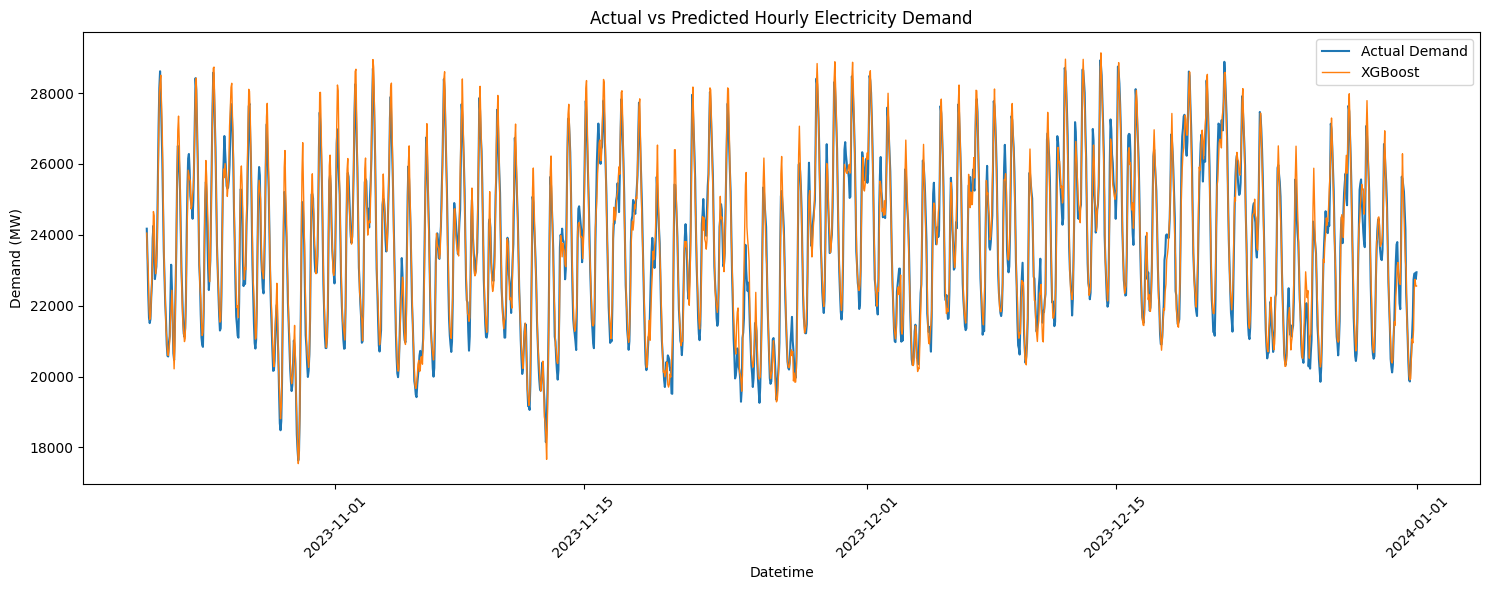

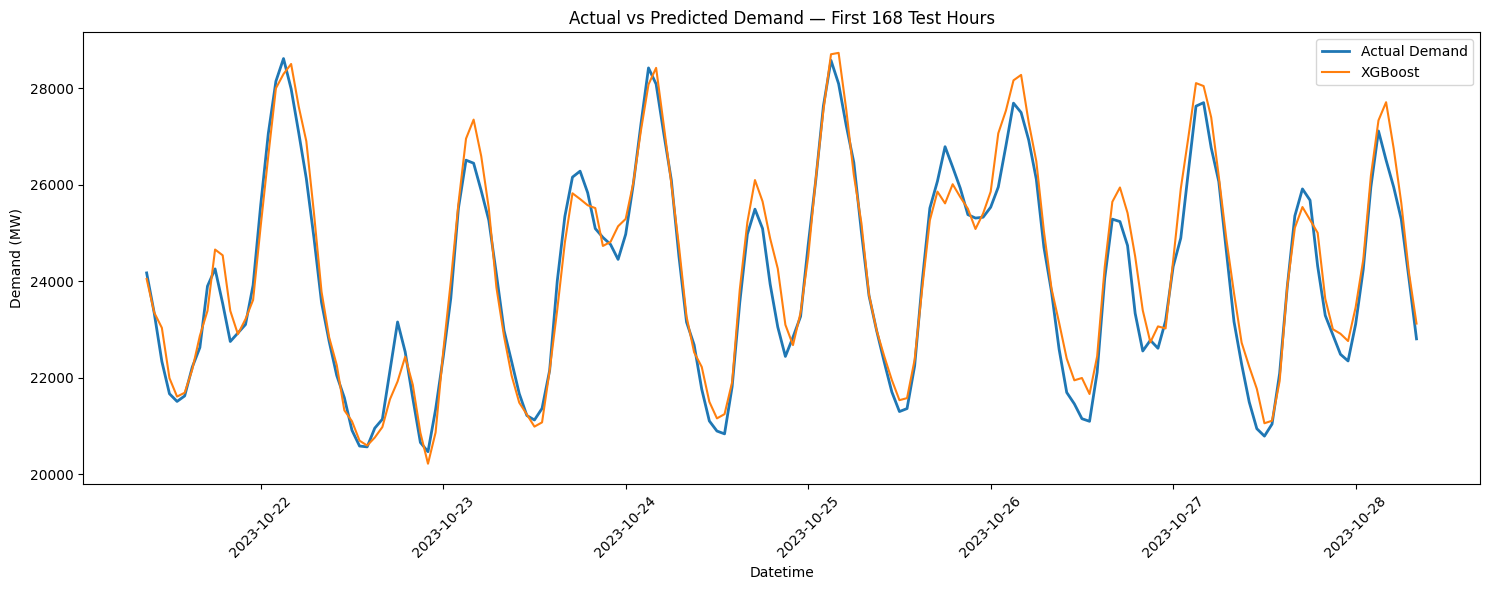


Top 15 XGBoost Features
----------------------


,Feature,Importance
0,demand_lag_1,0.830782
1,demand_lag_24,0.075468
2,is_weekend,0.026917
3,hour,0.017740
4,day_of_week,0.008028
5,demand_lag_168,0.006538
6,quarter,0.006049
7,temp_max,0.002276
8,month,0.002091
9,demand_roll_24,0.002028


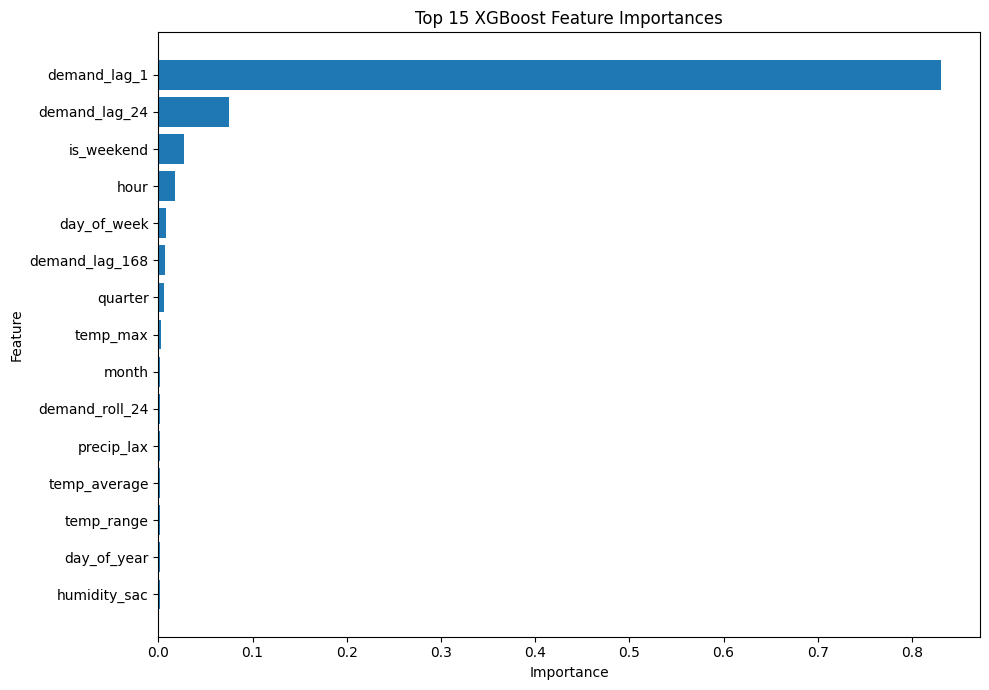

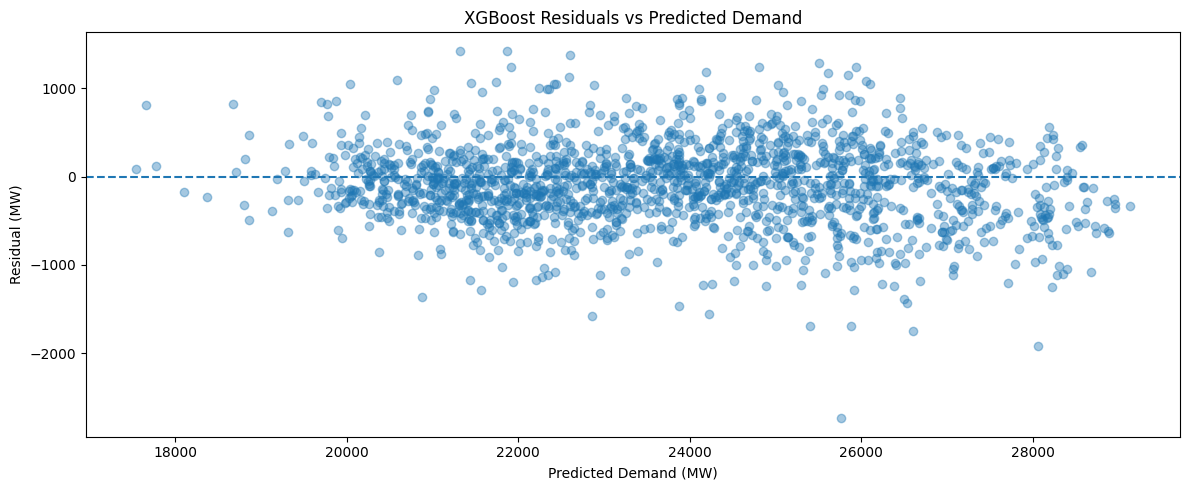


Files exported successfully:
../data/xgboost_predictions.csv
../data/enhanced_model_comparison.csv


In [54]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ---------------------------------------------------------
# 1. Confirm that the required variables exist
# ---------------------------------------------------------

required_variables = [
    "X_train_enhanced",
    "X_test_enhanced",
    "y_train_enhanced",
    "y_test_enhanced",
    "enhanced_data",
    "split_index"
]

missing_variables = [
    variable
    for variable in required_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "Run the feature-engineering and chronological split cell first. "
        f"Missing variables: {missing_variables}"
    )

# ---------------------------------------------------------
# 2. Train XGBoost
# ---------------------------------------------------------

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="rmse"
)

xgb_start_time = time.time()

xgb_model.fit(
    X_train_enhanced,
    y_train_enhanced
)

xgb_training_time = time.time() - xgb_start_time

print("XGBoost trained successfully.")
print(f"Training time: {xgb_training_time:.2f} seconds")

# ---------------------------------------------------------
# 3. Generate predictions
# ---------------------------------------------------------

xgb_pred = xgb_model.predict(X_test_enhanced)

# ---------------------------------------------------------
# 4. Evaluate XGBoost
# ---------------------------------------------------------

xgb_mae = mean_absolute_error(
    y_test_enhanced,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test_enhanced,
        xgb_pred
    )
)

xgb_mape = np.mean(
    np.abs(
        (y_test_enhanced.to_numpy() - xgb_pred)
        / y_test_enhanced.to_numpy()
    )
) * 100

xgb_r2 = r2_score(
    y_test_enhanced,
    xgb_pred
)

print("\nXGBoost Results")
print("----------------")
print(f"MAE : {xgb_mae:.2f} MW")
print(f"RMSE: {xgb_rmse:.2f} MW")
print(f"MAPE: {xgb_mape:.2f}%")
print(f"R²  : {xgb_r2:.4f}")

# ---------------------------------------------------------
# 5. Compare XGBoost with Enhanced Random Forest
# ---------------------------------------------------------

comparison_rows = []

# Add Random Forest only if its results still exist
if all(
    variable in globals()
    for variable in [
        "enhanced_mae",
        "enhanced_rmse",
        "enhanced_mape",
        "enhanced_r2"
    ]
):
    comparison_rows.append({
        "Model": "Enhanced Random Forest",
        "MAE_MW": enhanced_mae,
        "RMSE_MW": enhanced_rmse,
        "MAPE_Percent": enhanced_mape,
        "R2": enhanced_r2
    })
else:
    print(
        "\nRandom Forest metrics are not currently in memory. "
        "The XGBoost results will still be displayed."
    )

comparison_rows.append({
    "Model": "XGBoost",
    "MAE_MW": xgb_mae,
    "RMSE_MW": xgb_rmse,
    "MAPE_Percent": xgb_mape,
    "R2": xgb_r2
})

model_comparison = pd.DataFrame(comparison_rows)

model_comparison = model_comparison.sort_values(
    by="RMSE_MW"
).reset_index(drop=True)

print("\nModel Comparison")
print("----------------")
display(
    model_comparison.style.format({
        "MAE_MW": "{:.2f}",
        "RMSE_MW": "{:.2f}",
        "MAPE_Percent": "{:.2f}",
        "R2": "{:.4f}"
    })
)

# ---------------------------------------------------------
# 6. Build prediction results dataframe
# ---------------------------------------------------------

test_datetimes = (
    enhanced_data["datetime"]
    .iloc[split_index:]
    .reset_index(drop=True)
)

prediction_results = pd.DataFrame({
    "datetime": test_datetimes,
    "actual_demand": y_test_enhanced.reset_index(drop=True),
    "xgboost_prediction": xgb_pred
})

if "enhanced_pred" in globals():
    prediction_results["random_forest_prediction"] = enhanced_pred

display(prediction_results.head())

# ---------------------------------------------------------
# 7. Plot actual vs predicted demand
# ---------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    prediction_results["datetime"],
    prediction_results["actual_demand"],
    label="Actual Demand",
    linewidth=1.5
)

plt.plot(
    prediction_results["datetime"],
    prediction_results["xgboost_prediction"],
    label="XGBoost",
    linewidth=1
)

if "random_forest_prediction" in prediction_results.columns:
    plt.plot(
        prediction_results["datetime"],
        prediction_results["random_forest_prediction"],
        label="Random Forest",
        linewidth=1,
        alpha=0.8
    )

plt.title("Actual vs Predicted Hourly Electricity Demand")
plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8. Plot a shorter period for easier visual comparison
# ---------------------------------------------------------

plot_hours = min(168, len(prediction_results))

plt.figure(figsize=(15, 6))

plt.plot(
    prediction_results["datetime"].iloc[:plot_hours],
    prediction_results["actual_demand"].iloc[:plot_hours],
    label="Actual Demand",
    linewidth=2
)

plt.plot(
    prediction_results["datetime"].iloc[:plot_hours],
    prediction_results["xgboost_prediction"].iloc[:plot_hours],
    label="XGBoost",
    linewidth=1.5
)

if "random_forest_prediction" in prediction_results.columns:
    plt.plot(
        prediction_results["datetime"].iloc[:plot_hours],
        prediction_results["random_forest_prediction"].iloc[:plot_hours],
        label="Random Forest",
        linewidth=1.5,
        alpha=0.8
    )

plt.title("Actual vs Predicted Demand — First 168 Test Hours")
plt.xlabel("Datetime")
plt.ylabel("Demand (MW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 9. XGBoost feature importance
# ---------------------------------------------------------

xgb_importance = pd.DataFrame({
    "Feature": X_train_enhanced.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("\nTop 15 XGBoost Features")
print("----------------------")
display(xgb_importance.head(15))

top_features = xgb_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 10. Residual analysis
# ---------------------------------------------------------

xgb_residuals = (
    y_test_enhanced.reset_index(drop=True)
    - xgb_pred
)

plt.figure(figsize=(12, 5))

plt.scatter(
    xgb_pred,
    xgb_residuals,
    alpha=0.4
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("XGBoost Residuals vs Predicted Demand")
plt.xlabel("Predicted Demand (MW)")
plt.ylabel("Residual (MW)")
plt.tight_layout()
plt.show()


prediction_results.to_csv(
    "../data/xgboost_predictions.csv",
    index=False
)

model_comparison.to_csv(
    "../data/enhanced_model_comparison.csv",
    index=False
)

print("\nFiles exported successfully:")
print("../data/xgboost_predictions.csv")
print("../data/enhanced_model_comparison.csv")

In [55]:
# Recreate the complete model comparison table

import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Enhanced Random Forest",
        "XGBoost"
    ],
    "MAE_MW": [
        398.17,
        xgb_mae
    ],
    "RMSE_MW": [
        526.51,
        xgb_rmse
    ],
    "MAPE_Percent": [
        1.67,
        xgb_mape
    ],
    "R2": [
        0.9475,
        xgb_r2
    ]
})

model_comparison = model_comparison.sort_values(
    by="RMSE_MW"
).reset_index(drop=True)

display(
    model_comparison.style
    .format({
        "MAE_MW": "{:.2f}",
        "RMSE_MW": "{:.2f}",
        "MAPE_Percent": "{:.2f}",
        "R2": "{:.4f}"
    })
    .highlight_min(
        subset=["MAE_MW", "RMSE_MW", "MAPE_Percent"]
    )
    .highlight_max(
        subset=["R2"]
    )
)

model_comparison.to_csv(
    "../data/enhanced_model_comparison.csv",
    index=False
)

print("Model comparison saved successfully.")

,Model,MAE_MW,RMSE_MW,MAPE_Percent,R2
0,XGBoost,354.48,461.88,1.50,0.9596
1,Enhanced Random Forest,398.17,526.51,1.67,0.9475


Model comparison saved successfully.


# conclusion

The XGBoost model outperformed the enhanced Random Forest model across all evaluation metrics. It achieved an MAE of 354.48 MW, an RMSE of 461.88 MW, a MAPE of 1.50%, and an R² of 0.9596. These results indicate that XGBoost captured the nonlinear relationships among weather conditions, temporal patterns, and historical electricity demand more effectively. Based on predictive accuracy, XGBoost is the best-performing weather-enhanced model.

# XGBoost Feature Importance

The XGBoost feature importance analysis revealed that historical electricity demand was the dominant predictor of future demand. In particular, the one-hour lag (demand_lag_1) accounted for the majority of the model's predictive power, followed by the 24-hour lag (demand_lag_24). Time-based variables such as weekends, hour of the day, and day of the week also contributed substantially. Weather variables, including temperature and precipitation, improved the model but had a comparatively smaller influence. These findings indicate that electricity demand is driven primarily by temporal consumption patterns, with weather acting as a complementary predictor.

 # model comparison

In [57]:
import pandas as pd

comparison = pd.DataFrame({

    "Model": [
        "SARIMA",
        "Prophet",
        "Hybrid (SARIMA + Prophet)",
        "Weather-only Random Forest",
        "Enhanced Random Forest",
        "XGBoost"
    ],

    "MAE (MWh)": [
        1214.92,
        3047.00,
        1261.45,
        1939.99,
        398.17,
        354.48
    ],

    "RMSE (MWh)": [
        1604.52,
        3728.00,
        1545.61,
        2403.55,
        526.51,
        461.88
    ],

    "MAPE (%)": [
        5.25,
        13.05,
        5.35,
        None,
        1.67,
        1.50
    ],

    "R²": [
        None,
        None,
        None,
        0.0186,
        0.9475,
        0.9596
    ]
})

comparison

,Model,MAE (MWh),RMSE (MWh),MAPE (%),R²
0,SARIMA,1214.92,1604.52,5.25,NaN
1,Prophet,3047.00,3728.00,13.05,NaN
2,Hybrid (SARIMA + Prophet),1261.45,1545.61,5.35,NaN
3,Weather-only Random Forest,1939.99,2403.55,NaN,0.0186
4,Enhanced Random Forest,398.17,526.51,1.67,0.9475
5,XGBoost,354.48,461.88,1.50,0.9596


In [59]:
comparison.style.format({
    "MAE (MWh)": "{:.2f}",
    "RMSE (MWh)": "{:.2f}",
    "MAPE (%)": "{:.2f}",
    "R²": "{:.4f}"
}).highlight_min(
    subset=["MAE (MWh)", "RMSE (MWh)", "MAPE (%)"],
    color="lightgreen"
).highlight_max(
    subset=["R²"],
    color="lightgreen"
)

,Model,MAE (MWh),RMSE (MWh),MAPE (%),R²
0,SARIMA,1214.92,1604.52,5.25,nan
1,Prophet,3047.00,3728.00,13.05,nan
2,Hybrid (SARIMA + Prophet),1261.45,1545.61,5.35,nan
3,Weather-only Random Forest,1939.99,2403.55,nan,0.0186
4,Enhanced Random Forest,398.17,526.51,1.67,0.9475
5,XGBoost,354.48,461.88,1.50,0.9596


# Final model comparison table

In [63]:
comparison = pd.DataFrame({
    "Model": [
        "SARIMA",
        "Prophet",
        "Hybrid (SARIMA + Prophet)",
        "Weather-only Random Forest",
        "Enhanced Random Forest",
        "XGBoost"
    ],
    "MAE (MWh)": [
        1214.92,
        3047.00,
        1261.45,
        1939.99,
        398.17,
        354.48
    ],
    "RMSE (MWh)": [
        1604.52,
        3728.00,
        1545.61,
        2403.55,
        526.51,
        461.88
    ],
    "MAPE (%)": [
        5.25,
        13.05,
        5.35,
        None,
        1.67,
        1.50
    ],
    "R²": [
        None,
        None,
        None,
        0.0186,
        0.9475,
        0.9596
    ]
})

comparison.to_csv("../data/model_comparison.csv", index=False)

print(comparison)
print("Model comparison saved successfully.")

                        Model  MAE (MWh)  RMSE (MWh)  MAPE (%)      R²
0                      SARIMA    1214.92     1604.52      5.25     NaN
1                     Prophet    3047.00     3728.00     13.05     NaN
2   Hybrid (SARIMA + Prophet)    1261.45     1545.61      5.35     NaN
3  Weather-only Random Forest    1939.99     2403.55       NaN  0.0186
4      Enhanced Random Forest     398.17      526.51      1.67  0.9475
5                     XGBoost     354.48      461.88      1.50  0.9596
Model comparison saved successfully.


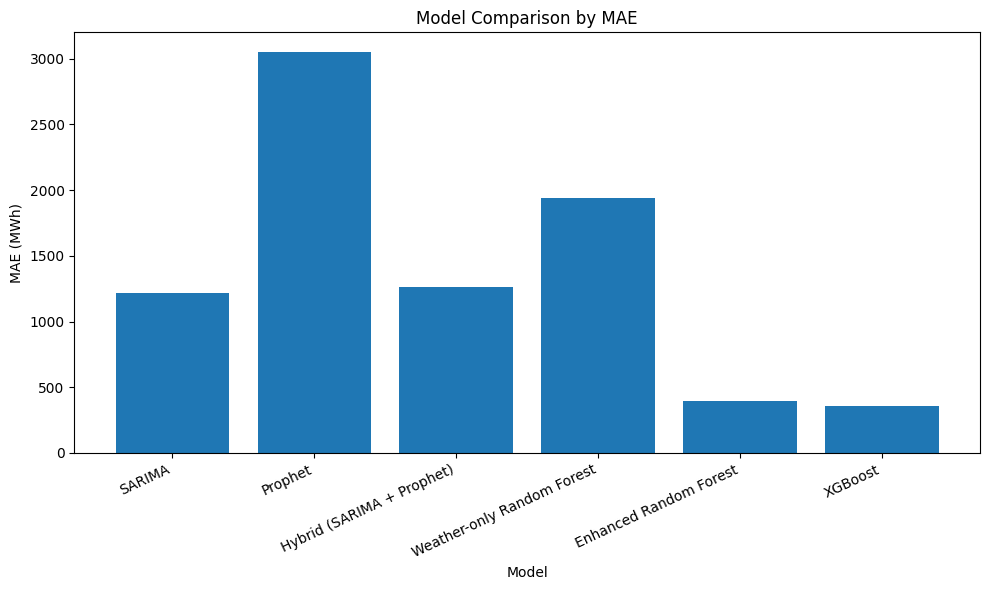

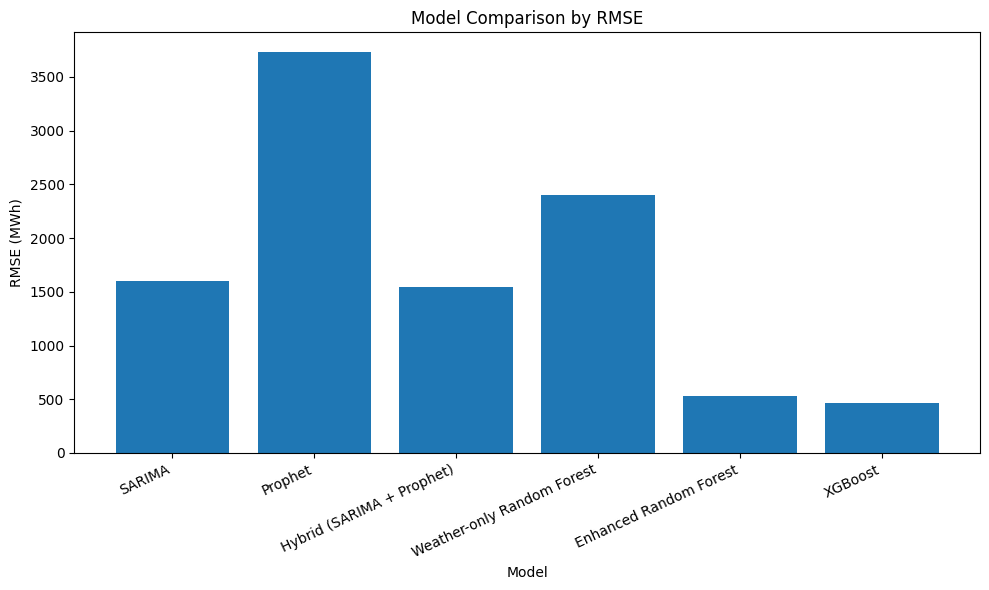

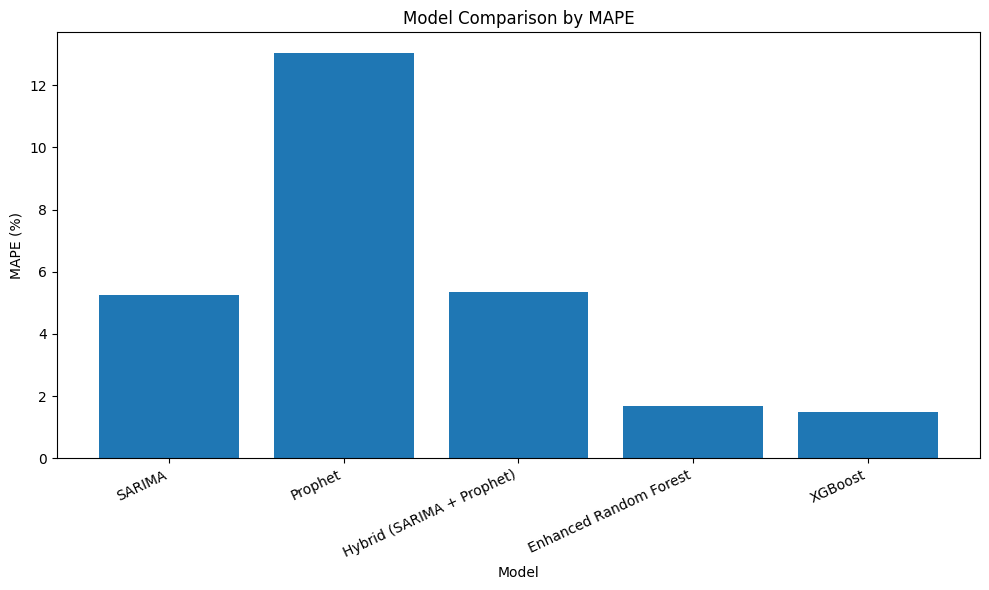

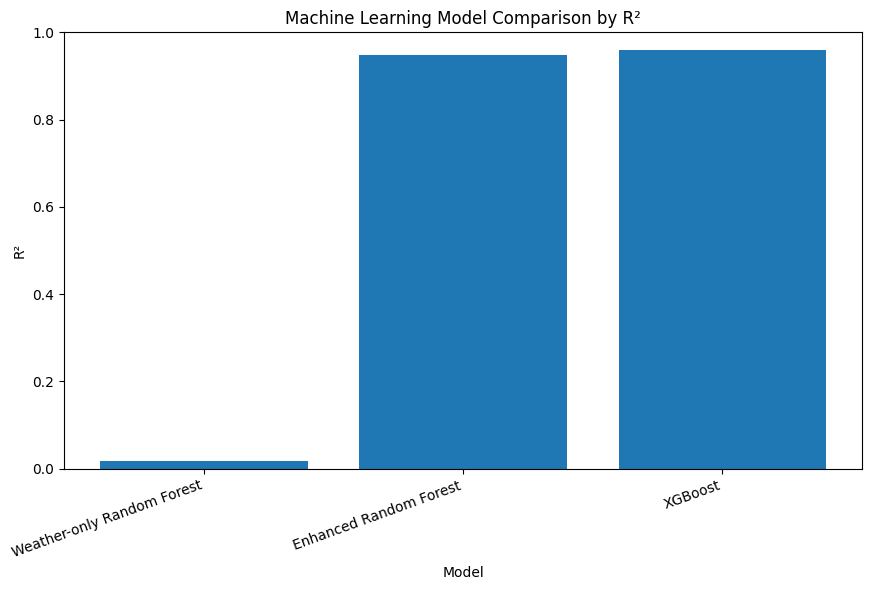

In [61]:
import matplotlib.pyplot as plt

# -----------------------------
# 1. MAE comparison
# -----------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Model"],
    comparison["MAE (MWh)"]
)

plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE (MWh)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


# -----------------------------
# 2. RMSE comparison
# -----------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Model"],
    comparison["RMSE (MWh)"]
)

plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE (MWh)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


# -----------------------------
# 3. MAPE comparison
# -----------------------------

mape_comparison = comparison.dropna(
    subset=["MAPE (%)"]
)

plt.figure(figsize=(10, 6))

plt.bar(
    mape_comparison["Model"],
    mape_comparison["MAPE (%)"]
)

plt.title("Model Comparison by MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


# -----------------------------
# 4. R² comparison
# -----------------------------

r2_comparison = comparison.dropna(
    subset=["R²"]
)

plt.figure(figsize=(9, 6))

plt.bar(
    r2_comparison["Model"],
    r2_comparison["R²"]
)

plt.title("Machine Learning Model Comparison by R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

The model-comparison charts show that XGBoost achieved the lowest MAE, RMSE, and MAPE among all evaluated models, indicating the highest overall forecasting accuracy. The Enhanced Random Forest was the second-best model, while SARIMA remained the strongest time-series model. Prophet produced the highest forecasting errors. Among the machine-learning models, XGBoost also achieved the highest R², explaining approximately 95.96% of the variability in hourly electricity demand.

# Final Project Conclusion:

This study developed and evaluated multiple forecasting approaches to predict hourly California Independent System Operator (CAISO) electricity demand using the 2023 hourly electricity demand dataset. The project progressed from traditional statistical time-series forecasting models to weather-enhanced machine learning models to determine the most accurate and reliable forecasting approach.

Exploratory data analysis and seasonal decomposition identified strong daily (24-hour), weekly (168-hour), and annual seasonal patterns in electricity demand, with noticeably higher demand during the summer months. Stationarity testing using the Augmented Dickey-Fuller (ADF) and KPSS tests confirmed that seasonal differencing was necessary before developing the statistical forecasting models.

Three statistical forecasting models—SARIMA, Prophet, and a Hybrid (SARIMA + Prophet) were first evaluated using only historical electricity demand data. Among these models, SARIMA achieved the highest overall forecasting accuracy with an MAE of 1,214.92 MWh and a MAPE of 5.25%, while the Hybrid model achieved the lowest RMSE of 1,545.61 MWh. Prophet effectively captured long-term trends and seasonality but produced higher forecasting errors for short-term hourly demand.

The second phase of the study incorporated NOAA weather observations, including temperature, humidity, wind speed, and precipitation, together with feature engineering techniques such as time-based variables, lag features, and rolling averages. The weather-only Random Forest model demonstrated limited predictive capability (R² = 0.0186), indicating that weather variables alone cannot adequately explain electricity demand. However, incorporating temporal and historical demand features substantially improved forecasting performance. The Enhanced Random Forest model achieved an MAE of 398.17 MWh, RMSE of 526.51 MWh, MAPE of 1.67%, and an R² of 0.9475.

Among all models evaluated, XGBoost produced the best overall forecasting performance. It achieved the lowest MAE (354.48 MWh), lowest RMSE (461.88 MWh), lowest MAPE (1.50%), and the highest R² (0.9596), explaining approximately 95.96% of the variability in hourly electricity demand. Feature importance analysis further demonstrated that historical demand (particularly the one-hour and 24-hour lag features) was the strongest predictor of future electricity demand. In contrast, weather variables and time-based features provided additional improvements in predictive accuracy.

Overall, the findings demonstrate that combining historical electricity demand with weather information and feature engineering significantly improves forecasting performance. While SARIMA remained the strongest traditional statistical forecasting model, XGBoost was the best-performing model within the scope of this study and is recommended for hourly electricity demand forecasting due to its superior predictive accuracy and ability to model complex nonlinear relationships among weather conditions, temporal patterns, and historical electricity demand.

# Key Findings:
Hourly CAISO electricity demand exhibits strong daily, weekly, and seasonal patterns.
SARIMA was the best-performing traditional statistical forecasting model, achieving an MAE of 1,214.92 MWh and a MAPE of 5.25%.
The Hybrid (SARIMA + Prophet) model achieved the lowest RMSE (1,545.61 MWh) among the statistical models, demonstrating improved performance in reducing larger forecasting errors.
Weather variables alone provided limited predictive capability (R² = 0.0186), indicating that electricity demand is influenced by multiple interacting factors beyond weather.
Feature engineering, including lag variables, rolling averages, and time-based features, substantially improved forecasting accuracy.
Historical demand, particularly the one-hour and 24-hour lag features, was the most influential predictor of future electricity demand.
XGBoost achieved the highest overall forecasting performance (MAE = 354.48 MWh, RMSE = 461.88 MWh, MAPE = 1.50%, R² = 0.9596) and outperformed all other evaluated models.

# Limitations:

- The study utilized only one year (2023) of electricity demand and weather data. Incorporating multiple years of observations would likely improve the model's ability to generalize across different climatic and operational conditions.
Weather data were collected from five representative California locations and may not fully capture localized weather variations across the entire CAISO service region.

- Additional explanatory variables, such as electricity prices, renewable energy generation, holidays, economic activity, population growth, and grid operational information, were not included in the forecasting models.

- Hyperparameter optimization was limited, and more extensive tuning could further improve model performance.

- Extreme or rare events, such as wildfires, prolonged heatwaves, power outages, or emergency grid conditions, were not explicitly modeled and may reduce forecasting accuracy during unusual demand periods.

  
# Future Work:

Future research should focus on extending and improving the forecasting framework by:

- Expanding the dataset to include multiple years of historical electricity demand and weather observations.
- Incorporating additional exogenous variables, including renewable energy generation, electricity prices, holidays, economic indicators, and grid operational data.
- Evaluating SARIMAX models with weather variables as exogenous regressors to compare traditional statistical forecasting with weather-enhanced machine learning models.
- Investigating advanced deep-learning models, including Long Short-Term Memory (LSTM), Gated Recurrent Unit (GRU), Transformer-based architectures, and Temporal Fusion Transformers, for long-term electricity demand forecasting.
-  Performing systematic hyperparameter optimization and time-series cross-validation to further improve model robustness and generalization.
-  Deploying the forecasting framework through an interactive Streamlit dashboard that integrates automated Large Language Model (LLM) commentary to provide interpretable forecast summaries, explain demand trends, and support operational decision-making for energy system stakeholders.